In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium


**1. Data Cleaning:**

In [2]:
df = pd.read_csv('globalterrorismdb_0718dist.csv', encoding='windows-1252', low_memory=False)
df.head()

,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,197000000001,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
1,197000000002,1970,0,0,NaN,0,NaN,130,Mexico,1,...,NaN,NaN,NaN,NaN,PGIS,0,1,1,1,NaN
2,197001000001,1970,1,0,NaN,0,NaN,160,Philippines,5,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
3,197001000002,1970,1,0,NaN,0,NaN,78,Greece,8,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
4,197001000003,1970,1,0,NaN,0,NaN,101,Japan,4,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN


In [3]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print(f"Name of Columns: {df.columns}")

Number of rows: 181691
Number of columns: 135
Name of Columns: Index(['eventid', 'iyear', 'imonth', 'iday', 'approxdate', 'extended',
       'resolution', 'country', 'country_txt', 'region',
       ...
       'addnotes', 'scite1', 'scite2', 'scite3', 'dbsource', 'INT_LOG',
       'INT_IDEO', 'INT_MISC', 'INT_ANY', 'related'],
      dtype='object', length=135)


In [4]:
df.dtypes.value_counts()

,count
object,58
float64,55
int64,22


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181691 entries, 0 to 181690
Columns: 135 entries, eventid to related
dtypes: float64(55), int64(22), object(58)
memory usage: 187.1+ MB


In [6]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values.head(20)

,0
gsubname3,181671
weapsubtype4,181621
weapsubtype4_txt,181621
weaptype4_txt,181618
weaptype4,181618
claimmode3,181558
claimmode3_txt,181558
gsubname2,181531
claim3,181373
guncertain3,181371


In [7]:
# Percentage of missing values for each column
missing_ratio = df.isnull().mean()
cols_to_drop = missing_ratio[missing_ratio > 0.5].index # Select those that exceed 50%
print(f"Columns with more 50% of missing values: ({len(cols_to_drop)} columns) :\n")
print(cols_to_drop)

Columns with more 50% of missing values: (77 columns) :

Index(['approxdate', 'resolution', 'location', 'alternative',
       'alternative_txt', 'attacktype2', 'attacktype2_txt', 'attacktype3',
       'attacktype3_txt', 'targtype2', 'targtype2_txt', 'targsubtype2',
       'targsubtype2_txt', 'corp2', 'target2', 'natlty2', 'natlty2_txt',
       'targtype3', 'targtype3_txt', 'targsubtype3', 'targsubtype3_txt',
       'corp3', 'target3', 'natlty3', 'natlty3_txt', 'gsubname', 'gname2',
       'gsubname2', 'gname3', 'gsubname3', 'motive', 'guncertain2',
       'guncertain3', 'claimmode', 'claimmode_txt', 'claim2', 'claimmode2',
       'claimmode2_txt', 'claim3', 'claimmode3', 'claimmode3_txt', 'compclaim',
       'weaptype2', 'weaptype2_txt', 'weapsubtype2', 'weapsubtype2_txt',
       'weaptype3', 'weaptype3_txt', 'weapsubtype3', 'weapsubtype3_txt',
       'weaptype4', 'weaptype4_txt', 'weapsubtype4', 'weapsubtype4_txt',
       'propextent', 'propextent_txt', 'propvalue', 'propcomment', 'nh

In [8]:
df.drop(columns=cols_to_drop, inplace=True)


In [9]:
# Dataset updated
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}") # 135 - 77
print(f"Name of Columns: {df.columns}")

Number of rows: 181691
Number of columns: 58
Name of Columns: Index(['eventid', 'iyear', 'imonth', 'iday', 'extended', 'country',
       'country_txt', 'region', 'region_txt', 'provstate', 'city', 'latitude',
       'longitude', 'specificity', 'vicinity', 'summary', 'crit1', 'crit2',
       'crit3', 'doubtterr', 'multiple', 'success', 'suicide', 'attacktype1',
       'attacktype1_txt', 'targtype1', 'targtype1_txt', 'targsubtype1',
       'targsubtype1_txt', 'corp1', 'target1', 'natlty1', 'natlty1_txt',
       'gname', 'guncertain1', 'individual', 'nperps', 'nperpcap', 'claimed',
       'weaptype1', 'weaptype1_txt', 'weapsubtype1', 'weapsubtype1_txt',
       'weapdetail', 'nkill', 'nkillus', 'nkillter', 'nwound', 'nwoundus',
       'nwoundte', 'property', 'ishostkid', 'scite1', 'dbsource', 'INT_LOG',
       'INT_IDEO', 'INT_MISC', 'INT_ANY'],
      dtype='object')


In [10]:
df.isnull().sum().sort_values(ascending=False)

,0
nperps,71115
nperpcap,69489
nwoundte,69143
weapdetail,67670
nkillter,66958
scite1,66191
summary,66129
claimed,66120
nwoundus,64702
nkillus,64446


In [11]:
df.dtypes

,0
eventid,int64
iyear,int64
imonth,int64
iday,int64
extended,int64
country,int64
country_txt,object
region,int64
region_txt,object
provstate,object


In [12]:
# Columns with missing values

# ['provstate', 'city', 'latitude',
#        'longitude', 'specificity',  'summary', 'doubtterr', 'multiple',
#        'targtype1_txt', 'targsubtype1',
#        'targsubtype1_txt', 'corp1', 'target1', 'natlty1', 'natlty1_txt',
#        'guncertain1', 'nperps', 'nperpcap', 'claimed',
#        'weapsubtype1', 'weapsubtype1_txt',
#        'weapdetail', 'nkill', 'nkillus', 'nkillter', 'nwound', 'nwoundus',
#        'nwoundte', 'ishostkid', 'scite1']


In [13]:
# Numerical columns
numerical_cols = ['latitude', 'longitude', 'nkillus', 'nkillter', 'nwound',
                  'nwoundus', 'nwoundte', 'nkill', 'nperps', 'nperpcap'
]

# Fill with median
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].median())


In [14]:
# Categorical columms (text / object)
text_cols = ['provstate', 'city', 'summary', 'target1',
                    'natlty1_txt', 'weapsubtype1_txt',
                    'weapdetail',  'scite1', 'corp1',
                    'targtype1_txt', 'targsubtype1_txt'
]


# Fill with "Unknown"
df[text_cols] = df[text_cols].fillna('Unknown')

In [15]:
# Categorical encoded as number
categorical_encoded_cols = ['natlty1', 'weapsubtype1', 'targsubtype1',
                            'specificity'
]

# Fill with mode
for col in categorical_encoded_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [16]:
# Binary columns
binary_cols = ['claimed', 'guncertain1', 'ishostkid', 'doubtterr',
               'multiple'
]

# Fill with 0
df[binary_cols] = df[binary_cols].fillna(0)

In [17]:
df.isnull().sum()

,0
eventid,0
iyear,0
imonth,0
iday,0
extended,0
country,0
country_txt,0
region,0
region_txt,0
provstate,0


**2. Data Transformation:**


- Categorical Transformation:

In [18]:
for col in text_cols:
    print(f"{col}: {df[col].nunique()} unique values")

provstate: 2855 unique values
city: 36673 unique values
summary: 112493 unique values
target1: 86005 unique values
natlty1_txt: 216 unique values
weapsubtype1_txt: 31 unique values
weapdetail: 19149 unique values
scite1: 83989 unique values
corp1: 33237 unique values
targtype1_txt: 22 unique values
targsubtype1_txt: 113 unique values


In [19]:
# One-Hot Encoding
cols_for_one_hot = ['targtype1_txt', 'weapsubtype1_txt']
df = pd.get_dummies(df, columns=cols_for_one_hot, drop_first=True)

In [20]:
# Label Encoding
from sklearn.preprocessing import LabelEncoder

label_cols = ['city', 'provstate', 'corp1', 'target1']
le = LabelEncoder()

for col in label_cols:
    df[col] = le.fit_transform(df[col])


- Numerical Normalization:

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])


**3. Exploratory Data Analysis:**

- **Data Exploration:** Conduct exploratory data analysis on the cleaned and integrated dataset.

In [22]:
print(f"Shape:{df.shape}") # Rows and columns
df.columns.tolist() # Names of columns

Shape:(181691, 107)


['eventid',
 'iyear',
 'imonth',
 'iday',
 'extended',
 'country',
 'country_txt',
 'region',
 'region_txt',
 'provstate',
 'city',
 'latitude',
 'longitude',
 'specificity',
 'vicinity',
 'summary',
 'crit1',
 'crit2',
 'crit3',
 'doubtterr',
 'multiple',
 'success',
 'suicide',
 'attacktype1',
 'attacktype1_txt',
 'targtype1',
 'targsubtype1',
 'targsubtype1_txt',
 'corp1',
 'target1',
 'natlty1',
 'natlty1_txt',
 'gname',
 'guncertain1',
 'individual',
 'nperps',
 'nperpcap',
 'claimed',
 'weaptype1',
 'weaptype1_txt',
 'weapsubtype1',
 'weapdetail',
 'nkill',
 'nkillus',
 'nkillter',
 'nwound',
 'nwoundus',
 'nwoundte',
 'property',
 'ishostkid',
 'scite1',
 'dbsource',
 'INT_LOG',
 'INT_IDEO',
 'INT_MISC',
 'INT_ANY',
 'targtype1_txt_Airports & Aircraft',
 'targtype1_txt_Business',
 'targtype1_txt_Educational Institution',
 'targtype1_txt_Food or Water Supply',
 'targtype1_txt_Government (Diplomatic)',
 'targtype1_txt_Government (General)',
 'targtype1_txt_Journalists & Media',
 '

In [23]:
# Global statistic view
df[numerical_cols].describe()

,latitude,longitude,nkillus,nkillter,nwound,nwoundus,nwoundte,nkill,nperps,nperpcap
count,1.816910e+05,1.816910e+05,1.816910e+05,1.816910e+05,1.816910e+05,1.816910e+05,1.816910e+05,1.816910e+05,1.816910e+05,1.816910e+05
mean,-3.528252e-16,2.199780e-19,1.153663e-18,1.251431e-18,3.363220e-18,4.155141e-18,-8.603585e-18,1.759824e-17,1.314002e-17,-2.150896e-19
std,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00
min,-4.181967e+00,-4.262511e+02,-6.500731e-03,-9.586981e-02,-8.403747e-02,-1.022085e-02,-5.659290e-02,-2.019110e-01,-1.206240e-01,-9.700072e+00
25%,-6.447425e-01,2.239242e-03,-6.500731e-03,-9.586981e-02,-8.403747e-02,-1.022085e-02,-5.659290e-02,-2.019110e-01,-1.206240e-01,9.271111e-02
50%,4.227682e-01,2.420214e-03,-6.500731e-03,-9.586981e-02,-8.403747e-02,-1.022085e-02,-5.659290e-02,-2.019110e-01,-1.206240e-01,9.271111e-02
75%,5.898829e-01,2.544406e-03,-6.500731e-03,-9.586981e-02,-2.574484e-02,-1.022085e-02,-5.659290e-02,-2.376940e-02,-1.206240e-01,9.271111e-02
max,2.771664e+00,3.093429e-03,2.979584e+02,1.493155e+02,2.386534e+02,3.060992e+02,1.704503e+02,1.396392e+02,1.477636e+02,4.025301e+01


In [24]:
# Attacks per year
attacks_per_year = df['iyear'].value_counts().sort_index()
attacks_per_year

,count
iyear,
1970,651
1971,471
1972,568
1973,473
1974,581
1975,740
1976,923
1977,1319
1978,1526


*Geographic distribution*

In [25]:
print(df['country_txt'].nunique())
df['country_txt'].value_counts().head(20)

205


,count
country_txt,
Iraq,24636
Pakistan,14368
Afghanistan,12731
India,11960
Colombia,8306
Philippines,6908
Peru,6096
El Salvador,5320
United Kingdom,5235


In [26]:
print(df['region_txt'].nunique())
df['region_txt'].value_counts()


12


,count
region_txt,
Middle East & North Africa,50474
South Asia,44974
South America,18978
Sub-Saharan Africa,17550
Western Europe,16639
Southeast Asia,12485
Central America & Caribbean,10344
Eastern Europe,5144
North America,3456


*Attack types*

In [27]:
# What is most frequent
print(df['attacktype1_txt'].nunique())
attacks_type = df['attacktype1_txt'].value_counts()
attacks_type

9


,count
attacktype1_txt,
Bombing/Explosion,88255
Armed Assault,42669
Assassination,19312
Hostage Taking (Kidnapping),11158
Facility/Infrastructure Attack,10356
Unknown,7276
Unarmed Assault,1015
Hostage Taking (Barricade Incident),991
Hijacking,659


In [28]:
# most active Terrorist groups
print(df['gname'].nunique())
df['gname'].value_counts().head(10)


3537


,count
gname,
Unknown,82782
Taliban,7478
Islamic State of Iraq and the Levant (ISIL),5613
Shining Path (SL),4555
Farabundo Marti National Liberation Front (FMLN),3351
Al-Shabaab,3288
New People's Army (NPA),2772
Irish Republican Army (IRA),2671
Revolutionary Armed Forces of Colombia (FARC),2487


*Targets and weapons*

In [29]:
# Targets
target_type_counts = df.filter(like='targtype1_txt_').sum().sort_values(ascending=False)
target_type_counts

,0
targtype1_txt_Private Citizens & Property,43511
targtype1_txt_Military,27984
targtype1_txt_Police,24506
targtype1_txt_Government (General),21283
targtype1_txt_Business,20669
targtype1_txt_Transportation,6799
targtype1_txt_Utilities,6023
targtype1_txt_Unknown,5898
targtype1_txt_Religious Figures/Institutions,4440
targtype1_txt_Educational Institution,4322


In [30]:
df['targsubtype1_txt'].value_counts().head(35).sort_values(ascending=False)

,count
targsubtype1_txt,
Unnamed Civilian/Unspecified,11596
Police Security Forces/Officers,11178
Unknown,10373
Military Unit/Patrol/Convoy,8277
"Military Personnel (soldiers, troops, officers, forces)",7963
"Government Personnel (excluding police, military)",6610
Village/City/Town/Suburb,6542
Politician or Political Party Movement/Meeting/Rally,6306
"Police Building (headquarters, station, school)",5907


In [31]:
# Weapons
df['weaptype1_txt'].value_counts()

,count
weaptype1_txt,
Explosives,92426
Firearms,58524
Unknown,15157
Incendiary,11135
Melee,3655
Chemical,321
Sabotage Equipment,141
"Vehicle (not to include vehicle-borne explosives, i.e., car or truck bombs)",136
Other,114


*Deadliest attacks*

In [32]:
df[['iyear', 'country_txt', 'nkill', 'summary']].sort_values(by='nkill', ascending=False).head(10)


,iyear,country_txt,nkill,summary
133518,2014,Iraq,139.639217,06/12/2014: Assailants abducted approximately ...
73126,2001,United States,123.072051,09/11/2001: This was one of four related attac...
73127,2001,United States,122.982980,09/11/2001: This was one of four related attac...
55934,1994,Rwanda,104.901612,Unknown
136283,2014,Iraq,84.682544,08/03/2014: Assailants attacked Yizidi civilia...
133225,2014,Iraq,59.475513,06/10/2014: Assailants stormed Badush prison i...
179671,2017,Somalia,52.171709,10/14/2017: A suicide bomber detonated an expl...
76347,2004,Nepal,45.936754,03/21/2004: Nepalese Communist Party (Maoist) ...
136746,2014,Syria,45.847683,08/19/2014: Assailants attacked Tabqa Air Base...
170198,2016,Syria,38.365738,"12/10/2016: Assailants, including suicide bomb..."


- **Visualization:** Create visualizations to reveal patterns and insights related to terrorism events in their socio-economic context.


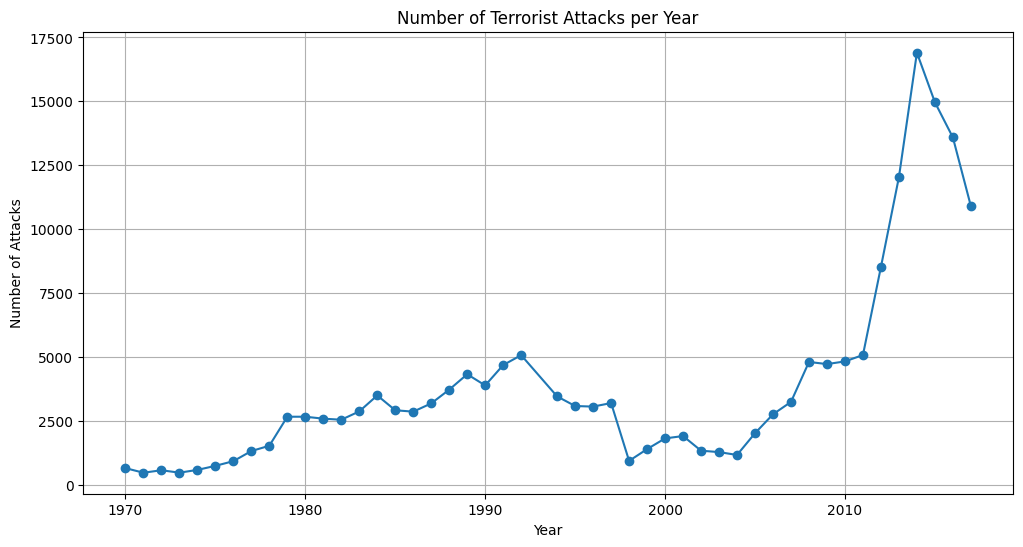

In [33]:
# Attacks per year
plt.figure(figsize=(12,6))
attacks_per_year.plot(kind='line', marker='o')
plt.title('Number of Terrorist Attacks per Year')
plt.xlabel('Year')
plt.ylabel('Number of Attacks')
plt.grid(True)
plt.show()

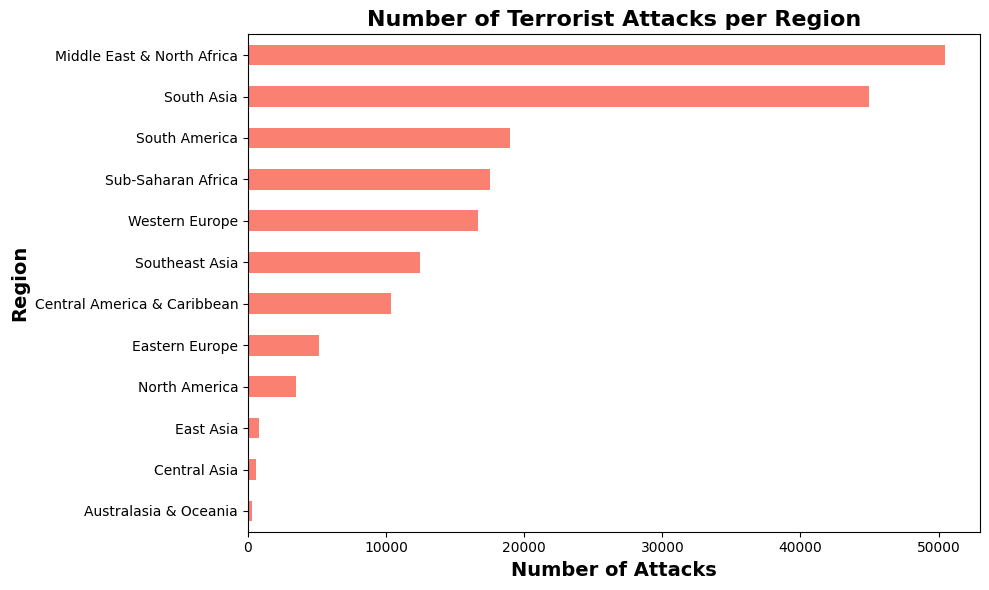

In [34]:
# Attack per region
df['region_txt'].value_counts().sort_values().plot(
    kind='barh', figsize=(10,6), color='salmon'
)
plt.title("Number of Terrorist Attacks per Region", fontsize=16, fontweight='bold')
plt.xlabel("Number of Attacks", fontsize=14, fontweight='bold')
plt.ylabel("Region", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


<Figure size 1200x600 with 0 Axes>

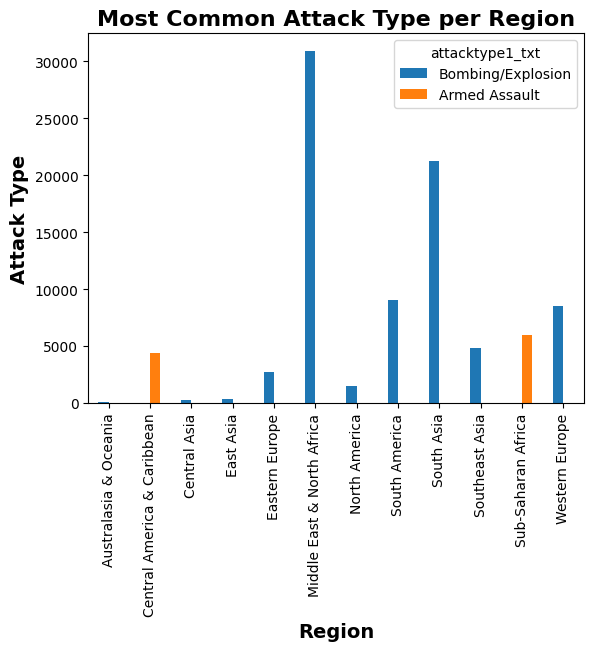

In [44]:
# Most common attack type per region
plt.figure(figsize=(12,6))
df.groupby('region_txt')['attacktype1_txt'].value_counts().groupby(level=0).head(1).unstack().plot(kind='bar')
plt.title("Most Common Attack Type per Region", fontsize=16, fontweight='bold')
plt.xlabel("Region", fontsize=14, fontweight='bold')
plt.ylabel("Attack Type", fontsize=14, fontweight='bold')
plt.show()

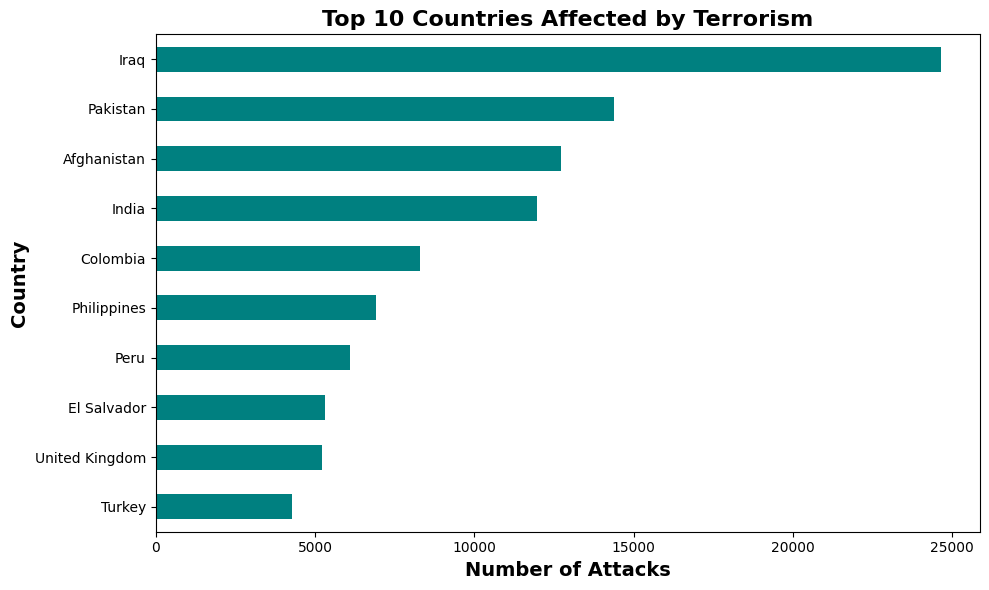

In [35]:
# Top 10 most affected countries
df['country_txt'].value_counts().head(10).sort_values().plot(
    kind='barh', figsize=(10,6), color='teal'
)
plt.title("Top 10 Countries Affected by Terrorism", fontsize=16, fontweight='bold')
plt.xlabel("Number of Attacks", fontsize=14, fontweight='bold')
plt.ylabel("Country", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


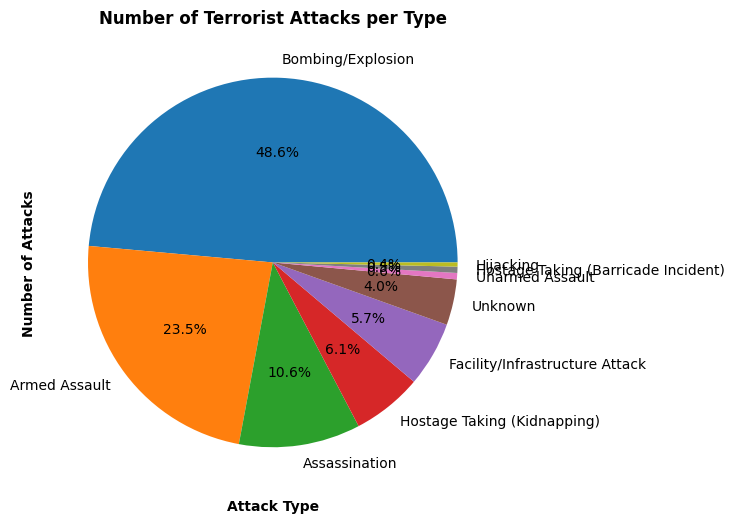

In [36]:
# Attacks type
plt.figure(figsize=(12,6))

attacks_type.plot(kind='pie', autopct='%1.1f%%')
plt.title('Number of Terrorist Attacks per Type', fontweight = 'bold')
plt.xlabel('Attack Type', fontweight = 'bold')
plt.ylabel('Number of Attacks', fontweight = 'bold')
plt.grid(True)

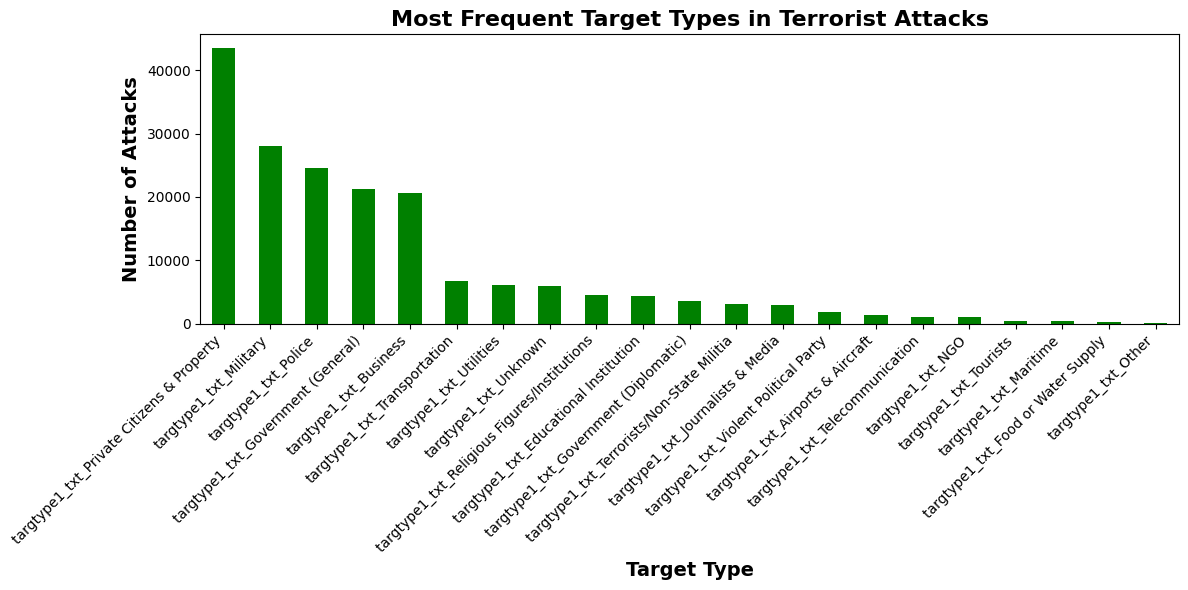

In [37]:
# Target type
plt.figure(figsize=(12,6))
target_type_counts.plot(kind='bar', color='green')
plt.title("Most Frequent Target Types in Terrorist Attacks", fontsize=16, fontweight='bold')
plt.xlabel("Target Type", fontsize=14, fontweight='bold')
plt.ylabel("Number of Attacks", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


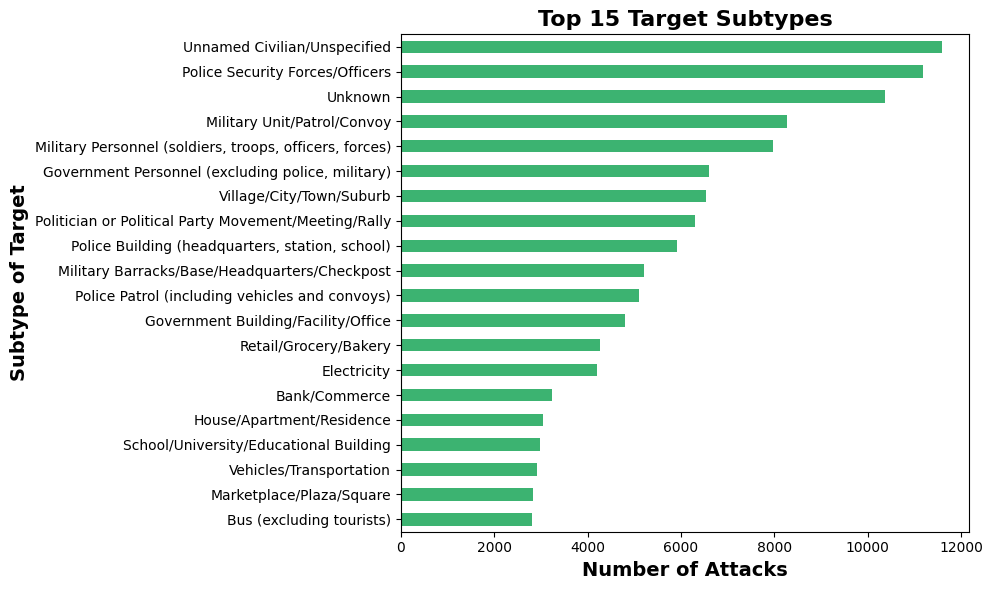

In [38]:
# Sub Target Type
df['targsubtype1_txt'].value_counts().head(20).sort_values().plot(
    kind='barh', figsize=(10,6), color='mediumseagreen'
)
plt.title("Top 15 Target Subtypes", fontsize=16, fontweight='bold')
plt.xlabel("Number of Attacks", fontsize=14, fontweight='bold')
plt.ylabel("Subtype of Target", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [39]:
# Number of attacks targeting religious targets
religious_attacks = df['targtype1_txt_Religious Figures/Institutions'].sum()

# Total attacks
target_type_counts = df.filter(like='targtype1_txt_').sum().sum()

# Proportion %
proportion = (religious_attacks / target_type_counts) * 100

print(f"Religious targets represent {religious_attacks} attacks, which is {proportion:.2f}% of all known target types.")

Religious targets represent 4440 attacks, which is 2.45% of all known target types.


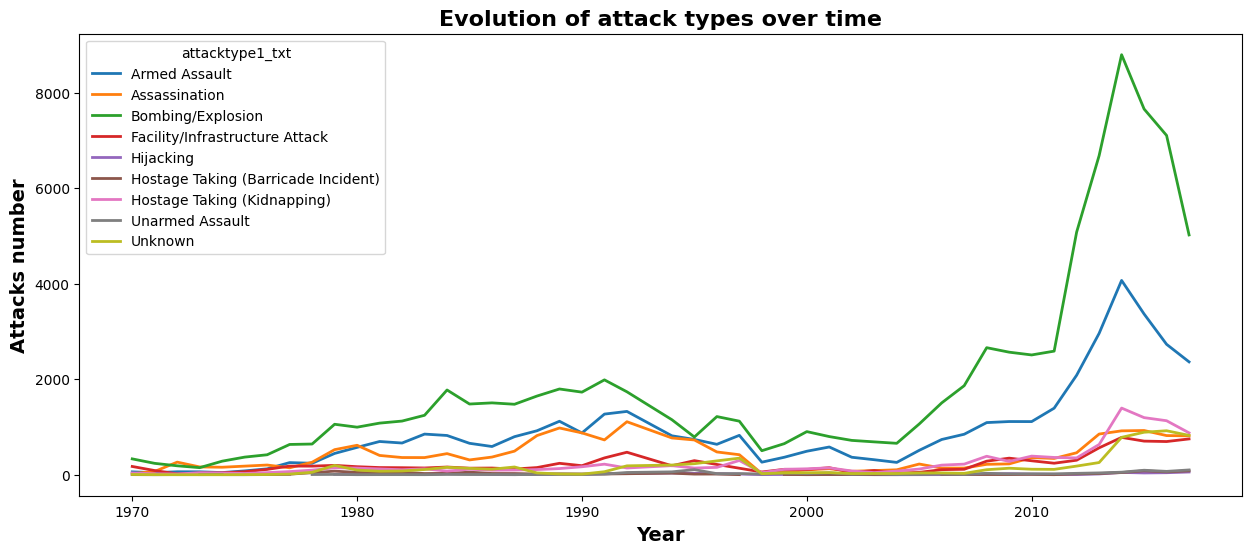

In [40]:
# Evolution of attack types over time

df.groupby(['iyear', 'attacktype1_txt']).size().unstack().plot(
    figsize=(15, 6), linewidth=2
)
plt.title("Evolution of attack types over time", fontsize=16, fontweight='bold')
plt.xlabel("Year", fontsize=14, fontweight='bold')
plt.ylabel("Attacks number", fontsize=14, fontweight='bold')
plt.show()

In [41]:
# Most active Terrorist group per country
df[df['gname'] != 'Unknown'].groupby('country_txt')['gname'].agg(lambda x: x.value_counts().index[0]).head(10)


,gname
country_txt,
Afghanistan,Taliban
Albania,Muslim extremists
Algeria,Algerian Islamic Extremists
Andorra,International Revolutionary Action Group (GARI)
Angola,National Union for the Total Independence of A...
Argentina,Montoneros (Argentina)
Armenia,Armenian Guerrillas
Australia,Jihadi-inspired extremists
Austria,Neo-Nazi extremists


In [42]:
df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')

# World Map
df_map = df[(df['latitude'].between(-90, 90)) & (df['longitude'].between(-180, 180))]

# Top 10 most affected countries
top_countries = df_map['country_txt'].value_counts().head(10).index.tolist()

# Sample up to 100 attacks per country
df_map_sample = df_map.sample(n=1000, random_state=42)

# Sample on 100 attacks by country
df_sampled = df_map[df_map['country_txt'].isin(top_countries)].\
groupby('country_txt').apply(lambda x: x.sample(min(100, len(x)), random_state=42)).reset_index(drop=True)

# Create the Map
world_map = folium.Map(location=[20, 0], zoom_start=2)

# Add markers with popups
for _, row in df_sampled.iterrows():
    lat, lon = float(row['latitude']), float(row['longitude'])  # ← force conversion
    popup_text = f"""
    <b>Country:</b> {row['country_txt']}<br>
    <b>City:</b> {row['city']}<br>
    <b>Year:</b> {row['iyear']}<br>
    <b>Attack Type:</b> {row['attacktype1_txt']}<br>
    <b>Killed:</b> {row['nkill']}
    """
    folium.CircleMarker(
        location=[lat, lon],
        radius=3,
        color='crimson',
        fill=True,
        fill_color='crimson',
        fill_opacity=0.7,
        popup=folium.Popup(popup_text, max_width=300)
    ).add_to(world_map)

world_map

<ipython-input-42-30a82d080f01>:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  groupby('country_txt').apply(lambda x: x.sample(min(100, len(x)), random_state=42)).reset_index(drop=True)


**Conclusion and Insights**
- The dataset contains **181,691 records across 135 columns**, spanning terrorism events worldwide from 1970 to 2017.
- Many columns had over 50% missing values. These were dropped to retain only the most informative features.

- **Visualizations**
 - Terrorist attacks have **increased** significantly over the decades, peaking in the early 2010s. This **rise in attacks** from 2003–2014 aligns with major geopolitical conflicts
 - The most affected countries include **Iraq, Pakistan, India, Afghanistan, and Colombia**.
 - The most common type of attack is **bombing/explosion**, followed by **armed assault** and **assassination**.
 - The most targeted groups are **private citizens & property, military, and police**, which raises concerns about the socio-psychological impact of terrorism.
 - Groups like **Taliban, ISIL, and Boko Haram** are among the most active globally.
 - Different regions have different dominant tactics (e.g. car bombs in Iraq, armed assault in Africa).
 - The variety in target subtypes can reflect underlying **social, political, or religious tensions.**